# Blinkit Analysis

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

# Import Raw Data

In [4]:
df = pd.read_csv("blinkit_data.csv")

# Sample Data

In [5]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [6]:
df.tail()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


# Meta Data

In [8]:
print("Size of Data: ", df.shape)

Size of Data:  (8523, 12)


In [16]:
print("Available Colums: \n", df.columns )

Available Colums: 
 Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')


In [14]:
print("Data Types:\n ", df.dtypes)

Data Types:
  Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object


In [18]:
print("Item Fat Content: ", df['Item Fat Content'].unique())

Item Fat Content:  ['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [34]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'low Fat':'Low Fat','LF':'Low Fat','reg':'Regular','low fat': 'Low Fat',})

In [35]:
print("Updated Item Fat Content: ", df['Item Fat Content'].unique())

Updated Item Fat Content:  ['Regular' 'Low Fat']


# KPI'S

In [25]:
#1.Total sales
total_sales = df['Sales'].sum()

#2.Average Sales
average_sales = df['Sales'].mean()

#3.No. of Items Sold
No_of_items_sold = df['Sales'].count()

#4.Average_Rating
average_rating = df['Rating'].mean()

In [29]:
print(f"Total Sales:  ${total_sales:,.0f}")
print(f"Average Sales:  ${average_sales:,.0f}")
print(f"No of Items Sold: { No_of_items_sold:,.0f}")
print(f"Average_rating: {average_rating:,.1f}")


Total Sales:  $1,201,681
Average Sales:  $141
No of Items Sold: 8,523
Average_rating: 4.0


# Charts

# Total Sales by Fat Content

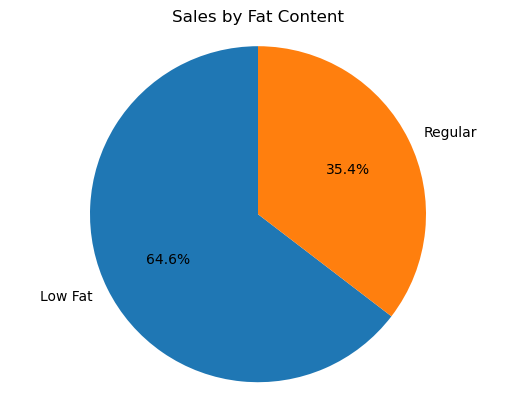

In [36]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()

plt.pie(sales_by_fat, labels=sales_by_fat.index, autopct='%.1f%%', startangle=90)

plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()

# Total Sales by Item Type

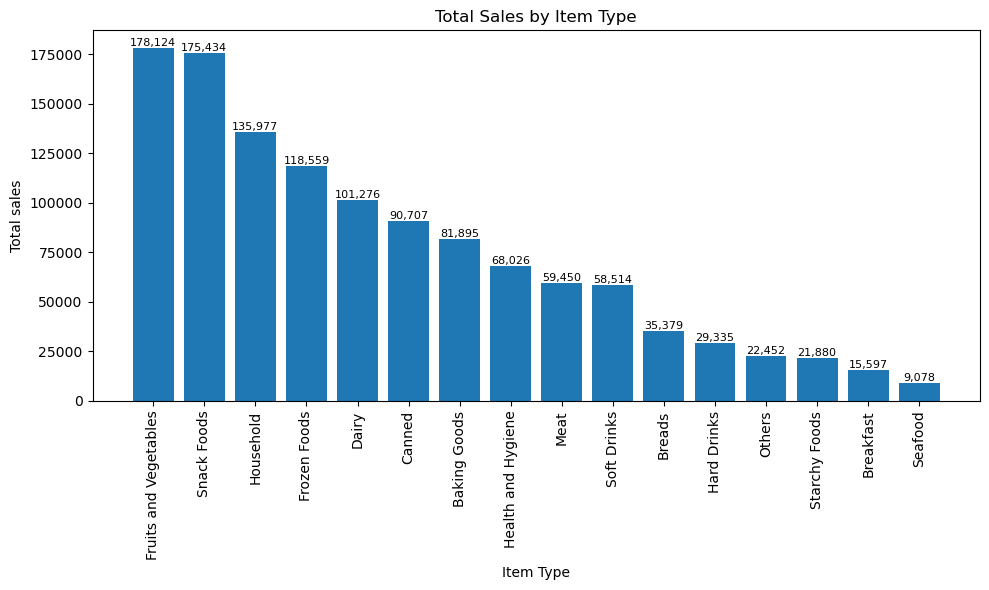

In [38]:
sales_by_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
bars = plt.bar(sales_by_type.index, sales_by_type.values)

plt.xticks(rotation=90)
plt.xlabel('Item Type')
plt.ylabel('Total sales')
plt.title('Total Sales by Item Type')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()



# Fat Content by Outlet for Total Sales

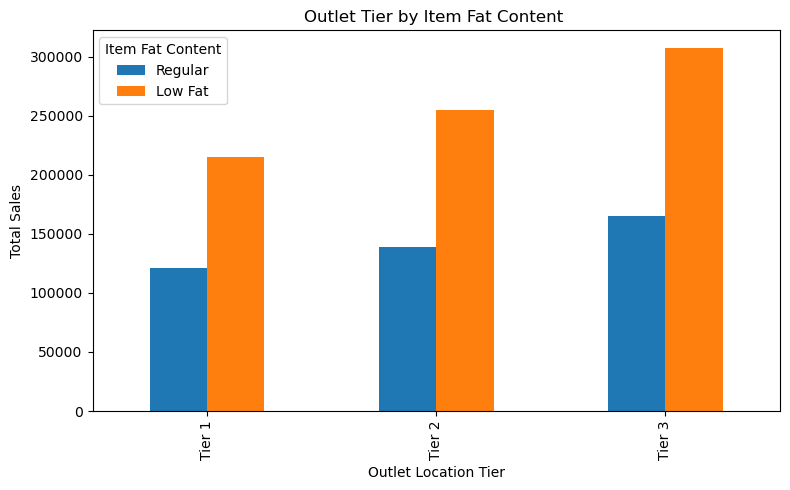

In [40]:
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular', 'Low Fat']]

ax = grouped.plot(kind='bar', figsize=(8,5), title='Outlet Tier by Item Fat Content ')

plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales') 
plt.legend(title='Item Fat Content')
plt.tight_layout()
plt.show()

# Total Sales by Outlet Establishment

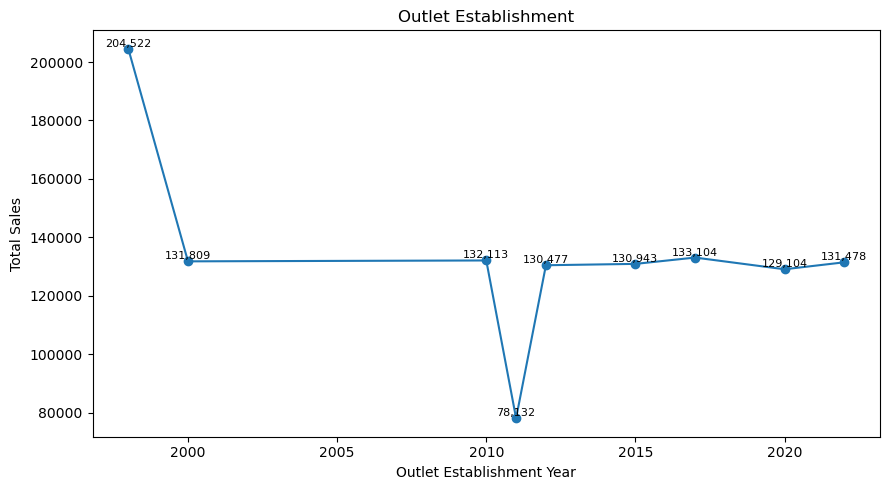

In [45]:
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize=(9,5))
plt.plot(sales_by_year.index, sales_by_year.values, marker='o', linestyle='-')

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales') 
plt.title('Outlet Establishment')

for x,y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize = 8)

plt.tight_layout()
plt.show()

# Sales by Outlet Size

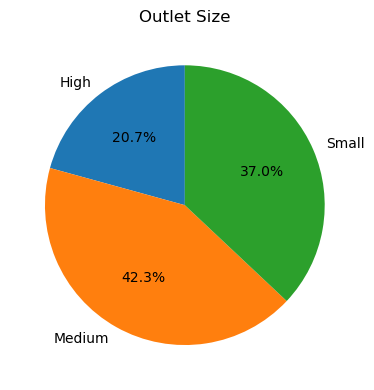

In [47]:
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize=(4,4))
plt.pie(sales_by_size, labels=sales_by_size.index, autopct='%1.1f%%', startangle=90)
plt.title('Outlet Size')
plt.tight_layout()
plt.show()

# Sales by Outlet Location

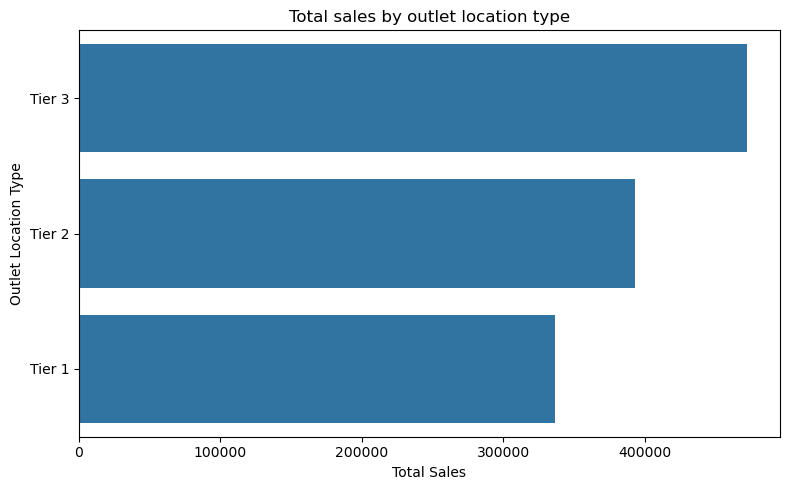

In [48]:
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
sales_by_location = sales_by_location.sort_values('Sales', ascending=False)

plt.figure(figsize=(8,5))
ax = sns.barplot(x='Sales', y='Outlet Location Type', data=sales_by_location)

plt.title('Total sales by outlet location type')
plt.xlabel('Total Sales')
plt.ylabel('Outlet Location Type')

plt.tight_layout()
plt.show()